In [24]:
import numpy as np

np1 = np.array(
    [[[2, 3, 1], [1, 4, 2], [6, 4, 2]]]
    )
np2 = np.array(
    [[[4, 6, 2], [2, 3, 6], [2, 3, 1]]]
    )

new_np = np1 * np2

np.sum(new_np)

# new_np.size

# np.clip(10, 0, 5)

print(isinstance(2, int))


True


Blurring stuff below

Text(0.5, 1.0, 'Auto CV2 Blurring')

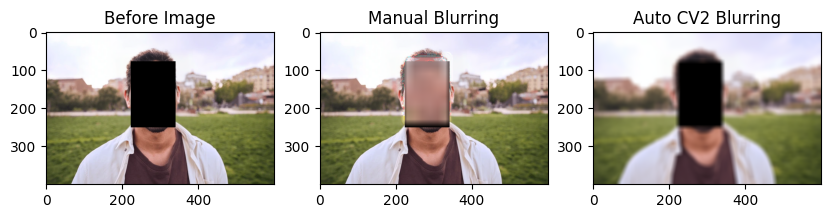

In [ ]:
from typing import List

import numpy as np
import cv2
import matplotlib.pyplot as plt

def blur(img: cv2.typing.MatLike, bbox: List | None = None):
    guassian_blur_filter = np.array(
        [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]]
    )


    RESCALE_FACTOR = 20
    
    resized_img = cv2.resize(img, (img.shape[1] // RESCALE_FACTOR, img.shape[0] // RESCALE_FACTOR))
    blurred_img = np.zeros((resized_img.shape[0], resized_img.shape[1], resized_img.shape[2]), dtype=np.uint8) if bbox is not None else resized_img.copy()

    H_RANGE_START = int(bbox[1]) // RESCALE_FACTOR if bbox is not None else 1
    H_RANGE_END = int(bbox[3]) // RESCALE_FACTOR if bbox is not None else resized_img.shape[0]-1

    W_RANGE_START = int(bbox[0]) // RESCALE_FACTOR if bbox is not None else 1
    W_RANGE_END = int(bbox[2]) // RESCALE_FACTOR if bbox is not None else resized_img.shape[1]-1

    for h in range(H_RANGE_START, H_RANGE_END):
        for w in range(W_RANGE_START, W_RANGE_END):

            top_left = resized_img[h-1][w-1]
            top_middle = resized_img[h-1][w]
            top_right = resized_img[h-1][w+1]

            middle_left = resized_img[h][w-1]
            middle_middle = resized_img[h][w]
            middle_right = resized_img[h][w+1]

            bottom_left = resized_img[h+1][w-1]
            bottom_middle = resized_img[h+1][w]
            bottom_right = resized_img[h+1][w+1]

            specificImg = np.array(
                [[top_left, top_middle, top_right],
                [middle_left, middle_middle, middle_right],
                [bottom_left, bottom_middle, bottom_right]]
            )


            filtered_point = np.sum(specificImg * guassian_blur_filter[:, :, None], axis=(0,1)) / np.sum(guassian_blur_filter) # will possobily need normalising and so on for this

            blurred_img[h][w] = filtered_point
        
    upscaled_img = cv2.resize(blurred_img, (img.shape[1], img.shape[0]))
    

    if bbox is not None:
        img[int(bbox[1]): int(bbox[3]), int(bbox[0]): int(bbox[2])] = (0, 0, 0)

    ret_img = np.bitwise_or(img, upscaled_img)

    # doesnt fully work not doing how i like it make sure to look into this and fix

    return ret_img

before_image = cv2.imread("deep_fake_analysis/test.png")

blurred_image = blur(before_image, [223.51405334472656, 77.07868957519531, 341.40570068359375, 251.74200439453125])

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(before_image, cv2.COLOR_BGR2RGB))
plt.title("Before Image")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.title("Manual Blurring")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(cv2.GaussianBlur(before_image, (15, 15), 10), cv2.COLOR_BGR2RGB))
plt.title("Auto CV2 Blurring")


